In [40]:
import pandas as pd
import io
from ast import literal_eval
import numpy as np
import heapq
import json
import math
import ssl
import os
import logging
import urllib

#from ibm_cloud_sdk_core.authenticators import IAMAuthenticator
#from ibm_watson import SpeechToTextV1

from pydub import AudioSegment
from yt_dlp import YoutubeDL
import parselmouth
import librosa
from scipy.io import wavfile
import resampy
from scipy import interpolate
#import pysptk
from pytube import YouTube
import os
import whisper_timestamped as whisper

from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from dtaidistance import dtw_ndim

import matplotlib.pyplot as plt
import seaborn as sns

In [196]:
# sens in percent
sens=20
n = 271

se = math.sqrt((sens - (1-sens)/n))
ci_95 = (sens - (1.96 * se), sens + (1.96 * se))

ci_95

(11.21926328436089, 28.780736715639108)

: 

In [41]:
FRAME_SIZE = 1024
HOP_LENGTH = 512
SAMPLE_RATE=16000.0

In [3]:
# def download_audio_youtube(url, name):
#     yt = YouTube(url,use_oauth=False, allow_oauth_cache=True)
#     video = yt.streams.filter(only_audio=True).first()
#     out_file = video.download(output_path='./')
#     title = yt.title

#     audio = AudioSegment.from_file(out_file)
#     new_file = name
#     #audio = audio.set_channels(1)  # Set to mono
#     #audio = audio.set_frame_rate(16000)  # Set the frame rate to 16000 Hz
#     audio.export(new_file, format="wav", codec="pcm_s16le")  # Export as 16-bit PCM WAV

#     os.remove(out_file)

#     return new_file, title

# def download_audio_youtube(url, name):
#     try:
#         logging.info(f"Attempting to download audio from: {url}")
#         yt = YouTube(url, use_oauth=False, allow_oauth_cache=True)

#         # Check for available audio streams
#         video = yt.streams.filter(only_audio=True).first()
#         if video is None:
#             logging.error("No audio streams available for this video.")
#             return None, None

#         # Download the audio file
#         out_file = video.download(output_path='./')
#         title = yt.title

#         # Process the audio file
#         audio = AudioSegment.from_file(out_file)
#         new_file = name

#         # Uncomment the next lines if you need to modify channels/frame rate
#         # audio = audio.set_channels(1)  # Set to mono
#         # audio = audio.set_frame_rate(16000)  # Set the frame rate to 16000 Hz

#         # Export the audio as WAV format
#         audio.export(new_file, format="wav", codec="pcm_s16le")

#         # Clean up the original downloaded file
#         os.remove(out_file)

#         return new_file, title

#     except urllib.error.HTTPError as e:
#         logging.error(f"HTTP Error {e.code}: {e.reason} while accessing {url}")
#     except Exception as e:
#         logging.exception(f"An error occurred while downloading audio: {e}")

#     return None, None


In [4]:
def download_audio_youtube(url, name):
    """
    Downloads audio from a YouTube video and saves it as a .wav file.

    Parameters:
        url (str): The URL of the YouTube video.
        name (str): The name of the output .wav file.

    Returns:
        tuple: The path to the saved audio file and the video title.
    """
    try:
        logging.info(f"Attempting to download audio from: {url}")
        
        # Set up yt-dlp options for audio-only download
        ydl_opts = {
            'format': 'bestaudio/best',
            'outtmpl': './%(title)s.%(ext)s',
            'postprocessors': [{
                'key': 'FFmpegExtractAudio',
                'preferredcodec': 'wav',
                'preferredquality': '192',
            }]
        }

        # Download audio using yt-dlp
        with YoutubeDL(ydl_opts) as ydl:
            info_dict = ydl.extract_info(url, download=True)
            title = info_dict.get('title', None)
            downloaded_file = f"./{title}.wav"

        # Rename and process the file if necessary
        if os.path.exists(downloaded_file):
            os.rename(downloaded_file, name)

        return name, title

    except Exception as e:
        logging.exception(f"An error occurred while downloading audio: {e}")

    return None, None

In [5]:
def pre_emphasis(signal, pre_emphasis_coefficient=0.97):
    return np.append(signal[0], signal[1:] - pre_emphasis_coefficient * signal[:-1])
def framing(signal, frame_size, frame_stride, sample_rate):
    frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate
    signal_length = len(signal)
    frame_length = int(round(frame_length))
    frame_step = int(round(frame_step))
    num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))

    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(signal, z)
    
    indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    frames = pad_signal[indices.astype(np.int32, copy=False)]
    return frames
def windowing(frames):
    return frames * np.hamming(frames.shape[1])
def power_spectrum(frames, NFFT):
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude of the FFT
    pow_frames = ((1.0 / NFFT) * (mag_frames ** 2))  # Power Spectrum
    return pow_frames
def mel_filter_bank(pow_frames, nfilt, NFFT, sample_rate):
    low_freq_mel = 0
    high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700))  # Convert Hz to Mel
    mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
    hz_points = (700 * (10**(mel_points / 2595) - 1))  # Convert Mel to Hz
    bin = np.floor((NFFT + 1) * hz_points / sample_rate)

    fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1])   # left
        f_m = int(bin[m])             # center
        f_m_plus = int(bin[m + 1])    # right

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)  # Numerical Stability
    filter_banks = 20 * np.log10(filter_banks)  # dB
    return filter_banks
from scipy.fftpack import dct
def compute_mfcc(filter_banks, num_ceps):
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)]
    return mfcc

In [6]:
def amplitude_envelope(signal, frame_size, hop_length):
    """Calculate the amplitude envelope of a signal with a given frame size nad hop length."""
    amplitude_envelope = []

    # calculate amplitude envelope for each frame
    for i in range(0, len(signal), hop_length):
        amplitude_envelope_current_frame = max(signal[i:i+frame_size])
        amplitude_envelope.append(amplitude_envelope_current_frame)

    return np.array(amplitude_envelope)

In [11]:
def process_audio_data(filename,isDataOne):
    def CalculateWindowDTW(startTime, endTime, isOne):
        print("STI1: "+str(startTimeIndex1))
        # print("STI2: "+str(startTimeIndex2))
        print("ETI1: "+str(endTimeIndex1))
        # print("ETI2: "+str(endTimeIndex2))
        print("ST: "+str(startTime))
        print("ET: "+str(endTime))
        if(startTime==None or endTime==None):
            print("MissingDTW")
            result = {
                "minDistIndex": -1,
                "isOne": isOne,
                "phraseStart": -1,
                "phraseEnd": -1,
                "dists": []  # Convert numpy array to list for JSON serialization
            }    
            return jsonify(result)
        windowData=(
            (savedComparisonData1 if isOne else savedComparisonData2)
            [(startTimeIndex1 if isOne else startTimeIndex2)[startTime]:
            (endTimeIndex1 if isOne else endTimeIndex2)[endTime]]
        )
        #MFCC calculation for reference sample
        
        print("WD shape: "+str(windowData.shape))
        emphasized_signal1 = pre_emphasis(windowData.iloc[:,0].to_numpy())
        
        print("ES shape: "+str(emphasized_signal1.shape))
        # Framing
        frame_size = 0.025
        frame_stride = 0.01
        frames1 = framing(emphasized_signal1, frame_size, frame_stride, SAMPLE_RATE)

        # Windowing
        frames1 = windowing(frames1)

        # Fourier Transform and Power Spectrum
        NFFT = 512
        pow_frames1 = power_spectrum(frames1, NFFT)

        # Mel Filter Bank
        nfilt = 40
        filter_banks1 = mel_filter_bank(pow_frames1, nfilt, NFFT, SAMPLE_RATE)

        # MFCCs
        num_ceps = 12
        mfcc1 = compute_mfcc(filter_banks1, num_ceps)

        #MFCC END
        #-----------------------------------------------------------

        print("PS1: "+str(phraseStart1))
        
        # print("PS2: "+str(phraseStart2))
        
        print("PE1: "+str(phraseEnd1))
        
        # print("PE2: "+str(phraseEnd2))
        dists=np.empty(len(phraseStart1 if (not isOne) else phraseStart2))
        minDist=np.inf
        start=-1
        end=-1
        minDistIndex=-1
        for i in range(len(phraseStart1 if (not isOne) else phraseStart2)-1):
            compWindowData=(savedComparisonData1 if (not isOne) else savedComparisonData2)[(startTimeIndex1 if (not isOne) else startTimeIndex2)[(phraseStart1 if (not isOne) else phraseStart2)[i]]:(endTimeIndex1 if (not isOne) else endTimeIndex2)[(phraseEnd1 if (not isOne) else phraseEnd2)[i+1]]]
            print(str(type(windowData))+" "+str(type(compWindowData)))
            try:
                # Ensure all data is numeric and convert to numpy array with type float64
                windowData_array = windowData.to_numpy(dtype='float64')
                compWindowData_array = compWindowData.to_numpy(dtype='float64')

    
                print("windowData_array shape:", windowData_array.shape)
                print("compWindowData_array shape:", compWindowData_array.shape)
                    #MFCC calculation for comparison sample
                emphasized_signal2 = pre_emphasis(compWindowData.iloc[:,0].to_numpy())
                # Framing
                frame_size = 0.025
                frame_stride = 0.01
                frames2 = framing(emphasized_signal2, frame_size, frame_stride, SAMPLE_RATE)

                # Windowing
                frames2 = windowing(frames2)

                # Fourier Transform and Power Spectrum
                NFFT = 512
                pow_frames2 = power_spectrum(frames2, NFFT)

                # Mel Filter Bank
                nfilt = 40
                filter_banks2 = mel_filter_bank(pow_frames2, nfilt, NFFT, SAMPLE_RATE)

                # MFCCs
                num_ceps = 12
                mfcc2 = compute_mfcc(filter_banks2, num_ceps)

                #MFCC END
                #-----------------------------------------------------------



                # Calculate DTW distance
                d = dtw_ndim.distance_fast(mfcc1, mfcc2)
                dists[i]=d
                print("Dists "+str(i)+" : "+str(d))
                if(d<minDist):
                    minDist=d
                    start=(phraseStart1 if (not isOne) else phraseStart2)[i]
                    end=(phraseEnd1 if (not isOne) else phraseEnd2)[i]
                    minDistIndex=i
            except Exception as e:
                print(f"An error occurred: {e}")
        result = {
            "minDistIndex": minDistIndex,
            "isOne": isOne,
            "phraseStart": start,
            "phraseEnd": end,
            "dists": dists.tolist()  # Convert numpy array to list for JSON serialization
        }

        
        return jsonify(result)
        
    #Maybe adjust based on audio?
    MIN_SENTENCE_CONFIDENCE_THRESHOLD=0.4 #For sentence confidence
    MIN_WORD_CONFIDENCE_THRESHOLD=0.3 #For word confidence 
    # Add explanation for what is confidence TODO

    

    audio=whisper.load_audio(filename)
    results=whisper.transcribe(model, audio, language="en")
    
    with open('muddledData.json','w') as f:
        json.dump(results,f,indent=2,ensure_ascii=True)
    #BASIC FEATURES (w/o transcription needed)
             
    """audio,sr = librosa.load(filename)"""
    FRAME_SIZE = 512
    HOP_LENGTH=512
    
    snd = parselmouth.Sound(filename)


    ae = amplitude_envelope(audio, FRAME_SIZE, HOP_LENGTH)
    #Figure out units TODO
    np.savetxt('ampData.txt',ae,fmt='%f')
    frames = range(len(ae))
    
    t = librosa.frames_to_time(frames,sr=SAMPLE_RATE, hop_length=HOP_LENGTH)

    pitch = snd.to_pitch(time_step=(HOP_LENGTH/SAMPLE_RATE))
    pitch_values = pitch.selected_array['frequency']
#CHECK IF THIS IS EVEN USEFUL TODO
    #print("t: "+str(t[-1])+" \n tlen: "+str(len(t)))
    tck = interpolate.splrep(t, ae, s=0) #Expand variable names TODO
    #print("TCK: \n"+str(tck[-1])+"TCK \n")
    #print("\n PXS :" +str(pitch.xs()[-1])+"\n")
    stepNum = (int)(pitch.xs()[-1]*100)
    xnew = np.linspace(0,pitch.xs()[-1],num=stepNum)
    #print(str(pitch.xs()[-1])+" time compari "+str(t[-1]))
    #print("TCK: \n"+str(xnew)+"TCK \n")
    #print("LEN: "+str(len(xnew))+" 2: "+str(len(ae)))
    ynew = interpolate.splev(xnew, tck, der=0)
    avg_amp=np.nanmean(ynew)
    tckp = interpolate.splrep(pitch.xs(), pitch_values, s=0)
    xnewp = np.linspace(0, pitch.xs()[-1], num=stepNum)
    ynewp = interpolate.splev(xnewp, tckp, der=0)
    pvals = [p if (p >= 50 and p <= 350) else 0 for p in ynewp]
    #pvals= ynewp
    #print("Y1: "+str(ynewp))
    ynewp = np.array(pvals,dtype=float)
    avg_pitch=np.nanmean([p if (p!=0) else np.nan for p in ynewp]) #Removes 0s
    ##print("Y2: "+str(ynewp))
    inte = []
    pit = []


    phraseStart=[0]
    phraseEnd=[]
    
    """with open(filename, 'rb') as f:
        print("Reading "+filename)
        results = stt.recognize(audio = f, content_type = 'audio/wav', model = 'en-US_Multimedia', timestamps = True, speaker_labels = True).get_result()
   """ 
    #Transcription Values Calculation
    

    lst = []

    punctuation_symbols=[",", ".", ";", "?", "!"]
        
  #  print("len1: "+str(len(results["segments"])))
    
    for i in range(len(results["segments"])):
        if results["segments"][i]["confidence"]<MIN_SENTENCE_CONFIDENCE_THRESHOLD:
            print("Skipping Sentence "+str(i))
            continue #Skips sentence fully
     #   print("len2: "+str(len(results["segments"][i]["words"])))
        for j in range(len(results["segments"][i]["words"])):
            if results["segments"][i]["words"][j]["confidence"]<MIN_WORD_CONFIDENCE_THRESHOLD:
                print("Skipping Word "+str(i)+ ", "+str(j))
                continue #Skips word    
            lst.append([results["segments"][i]["words"][j]["text"],results["segments"][i]["words"][j]["start"],results["segments"][i]["words"][j]["end"],0,0,0,0,0,0,0])
            
            
    #        print(results["segments"][i]["words"][j]["text"])
   # print(lst)
    """for i in range(len(results['results'])):
        df_word = df_word.append(results['results'][i]['alternatives'][0]['timestamps'])
    """
    
    df_word = pd.DataFrame(lst, columns=['Word', 'Start', 'End','length','time_spent','std_time_spent','speed','post_space','amplitude','pitch'])
    
    #, 3: "length", 4: "time_spent", 5: "std_time_spent", 6: "speed", 7: "post_space", 8: "amplitude", 9:"pitch"
#    df_word = df_word.rename(columns={0: "Word", 1:"Start",2: "End"}).reset_index(drop=True)


    df_word["length"] = df_word["Word"].apply(len)
    df_word['time_spent'] = df_word['End'] - df_word['Start']
    df_word['std_time_spent'] = df_word['time_spent']/df_word['length']
    df_word["speed"] = df_word["length"]/df_word["time_spent"]
    #USELESS FIRST LINE?
    df_word["post_space"] = np.append(np.array(df_word["Start"][1:]) - np.array(df_word["End"][:-1]),0)
    

    post =  df_word['Start'][1:].values - df_word['End'][:-1].values
    df_word["time"] = df_word["Start"] + (df_word["End"] - df_word["Start"])/2

    df_word['post_space'] = np.append(post,[0])
    

    #print("YNEW\n" +str(ynew)+ "YNEW \n")
    #Probably update with frontend pause duration
    MIN_CLAUSE_PAUSE_DURATION=0.5
    ##print("\n \n \n YNEWP" +str(ynewp))
    t2=0
    startTimeIndex=[]
    endTimeIndex=[]
    for i in range(len(df_word)):
            t1 = df_word['Start'][i]
            t2 = df_word['End'][i]
            idx_amp = (xnew>t1) & (xnew<t2)
            #print("IDX: "+str(idx_amp))

            # This will return 0 if no element is True unless you check if any True exists
            if idx_amp.any():
                index_of_first_true = np.argmax(idx_amp)
            else:
                index_of_first_true = -1

            if idx_amp.any():
                index_of_last_true = len(idx_amp) - np.argmax(idx_amp[::-1]) - 1
            else:
                index_of_last_true = -1  # or any indicator for "not found"
            print("Word "+str(i)+" index: "+str(index_of_first_true)+" - "+str(index_of_last_true))
            startTimeIndex.append(int(index_of_first_true))
            endTimeIndex.append(int(index_of_last_true))
            #print("IDX: "+ str(sum(1 for x in idx_amp if x != 0 and not math.isnan(x)))+ "Last time: "+ str(xnew[-1])+" start time: "+str(t1))
           
            #print(str(xnew)+"-- --"+ str(df_word['Start'][i]))
            #print(ynew[idx_amp]) 
            all_nan = np.all(np.isnan(ynew[idx_amp]))
            int_avg=0
            if(not all_nan):
                 int_avg = np.nanmean(ynew[idx_amp])
            print(int_avg)

            norm_int_avg=int_avg/(avg_amp)
            inte.append(norm_int_avg)
            

            idx_p = (xnewp>t1) & (xnewp<t2)
            pit_avg=0
            all_nan2 = np.all(np.isnan(ynewp[idx_p]))
            if(not all_nan2):
                pit_avg = np.nanmean(ynewp[idx_p])
            norm_pit_avg=(pit_avg/(avg_pitch))
            pit.append(norm_pit_avg)


            #Check for clause ending
            hasPunctuation=False
            for sym in punctuation_symbols:
                 if sym in df_word['Word'][i]:
                      hasPunctuation=True
                      break
            if hasPunctuation or df_word['post_space'][i]>MIN_CLAUSE_PAUSE_DURATION:
                phraseStart.append(i)
                phraseEnd.append(i-1)

    print(type(phraseEnd), phraseEnd)
    print("About to append t2:", t2)    

    phraseEnd.append(i)
    
    print("Start: "+str(startTimeIndex))    
    print("End: "+str(endTimeIndex))

    try:
        if(isDataOne):
            global startTimeIndex1, endTimeIndex1
            startTimeIndex1=startTimeIndex
            endTimeIndex1=endTimeIndex
            with open('startTime1.json','w') as f:
                json.dump(startTimeIndex,f,indent=2,ensure_ascii=True)
            with open('endTime1.json','w') as f:
                json.dump(endTimeIndex,f,indent=2,ensure_ascii=True)
        else:
            
            global startTimeIndex2, endTimeIndex2
            startTimeIndex2=startTimeIndex
            endTimeIndex2=endTimeIndex
            with open('startTime2.json','w') as f:
                json.dump(startTimeIndex,f,indent=2,ensure_ascii=True)
            with open('endTime2.json','w') as f:
                json.dump(endTimeIndex,f,indent=2,ensure_ascii=True)
    except Exception as e:
        print("Error occurred:", e)    

    df_word['amplitude'] = inte
    df_word['pitch'] = pit

#NORMALIZE TIME SPENT?

        
    tcks=interpolate.splrep(df_word['time'],df_word['std_time_spent'],s=0)
    xnews=np.linspace(0,pitch.xs()[-1],num=stepNum)
    ynews=interpolate.splev(xnews,tcks,der=0)
    avg_speed=np.nanmean(ynews)
         
    #YNEWS-Speaking speed array

    print("isOne: "+str(isDataOne))
    global phraseStart1, phraseEnd1, phraseStart2, phraseEnd2, savedComparisonData1, savedComparisonData2
    if(isDataOne):
         
         savedComparisonData1=pd.DataFrame(columns=['Amp', 'Pitch', 'Speed'])
         print("Length of ynew:", len(ynew))
         print("DataFrame size:", len(savedComparisonData1))
         print("ynewp: "+str(ynewp))
         savedComparisonData1['Amp']=[p/(avg_amp) for p in ynew]
         savedComparisonData1['Pitch']=[p/(avg_pitch) for p in ynewp]
         savedComparisonData1['Speed']=[p/avg_speed for p in ynews]
         
         phraseStart1=phraseStart
         phraseEnd1=phraseEnd
         savedComparisonData1.to_csv('ComparisonData1.csv',index=False)
         print(savedComparisonData1)
    else:
         
         savedComparisonData2=pd.DataFrame(columns=['Amp', 'Pitch', 'Speed'])
         print("Length of ynew:", len(ynew))
         print("DataFrame size:", len(savedComparisonData2))
         
         print("ynewp: "+str(ynewp))
         savedComparisonData2['Amp']=[p/(avg_amp) for p in ynew]
         savedComparisonData2['Pitch']=[p/(avg_pitch) for p in ynewp]
         savedComparisonData2['Speed']=[p/avg_speed for p in ynews]
         savedComparisonData2.to_csv('ComparisonData2.csv',index=False)

         phraseStart2=phraseStart
         phraseEnd2=phraseEnd
         print(savedComparisonData2)
    print("PS: "+str(phraseStart))

    print("PE: "+str(phraseEnd))
    try:
        if(isDataOne):
            with open('phraseStart1.json','w') as f:
                json.dump(phraseStart,f,indent=2,ensure_ascii=True)
            with open('phraseEnd1.json','w') as f:
                json.dump(phraseEnd,f,indent=2,ensure_ascii=True)
        else:
            with open('phraseStart2.json','w') as f:
                json.dump(phraseStart,f,indent=2,ensure_ascii=True)
            with open('phraseEnd2.json','w') as f:
                json.dump(phraseEnd,f,indent=2,ensure_ascii=True)
    except Exception as e:
        print("Error occurred:", e)
    """matches=[]
    for i in range(len(phraseStart)-1):
         print("Calculating window from: "+str(phraseStart[i])+" : "+str(phraseEnd[i+1]))
         matches.append(CalculateWindowDTW(phraseStart[i],phraseEnd[i+1],isDataOne)['minDistIndex'])"""

    return df_word, avg_amp, avg_pitch, avg_speed, phraseStart,phraseEnd

In [8]:
url = 'https://www.youtube.com/watch?v=O_JAZNbj8Pg'
new_file, title = download_audio_youtube(url, 'test')

[youtube] Extracting URL: https://www.youtube.com/watch?v=O_JAZNbj8Pg
[youtube] O_JAZNbj8Pg: Downloading webpage
[youtube] O_JAZNbj8Pg: Downloading ios player API JSON
[youtube] O_JAZNbj8Pg: Downloading mweb player API JSON
[youtube] O_JAZNbj8Pg: Downloading m3u8 information
[youtube] O_JAZNbj8Pg: Downloading MPD manifest
[info] O_JAZNbj8Pg: Downloading 1 format(s): 251
[download] Destination: ./Augmenting Human and Machine Intelligence with Data Visualization (Martin Wattenberg).webm
[download] 100% of    5.89MiB in 00:00:00 at 11.02MiB/s  
[ExtractAudio] Destination: ./Augmenting Human and Machine Intelligence with Data Visualization (Martin Wattenberg).wav
Deleting original file ./Augmenting Human and Machine Intelligence with Data Visualization (Martin Wattenberg).webm (pass -k to keep)


In [9]:
model=whisper.load_model("medium")

/Users/iliang/anaconda3/envs/prosody/lib/python3.12/site-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_loca

In [12]:
df_word, avg_amp, avg_pitch, avg_speed, phraseStart,phraseEnd = process_audio_data('test', 1)

100%|██████████| 31312/31312 [03:38<00:00, 143.03frames/s]


Skipping Word 0, 0
Skipping Word 13, 0
Word 0 index: 1578 - 1585
0.1508675355529251
Word 1 index: 1586 - 1597
0.07984011983050072
Word 2 index: 1598 - 1625
0.08236919071015154
Word 3 index: 1626 - 1651
0.1428367523208908
Word 4 index: 1652 - 1723
0.06246758886508578
Word 5 index: 1724 - 1767
0.020871479708392704
Word 6 index: 1792 - 1815
0.05755048932638207
Word 7 index: 1816 - 1825
0.020581746675535254
Word 8 index: 1826 - 1849
0.045157000750101435
Word 9 index: 1850 - 1913
0.029942188195137113
Word 10 index: 1914 - 1953
0.08852130254440652
Word 11 index: 1954 - 1973
0.06782217393730557
Word 12 index: 1974 - 1991
0.11304906523664451
Word 13 index: 1996 - 2019
0.05436118542985773
Word 14 index: 2020 - 2073
0.04630974257659023
Word 15 index: 2074 - 2115
0.032501527772433716
Word 16 index: 2116 - 2129
0.09051431498071812
Word 17 index: 2130 - 2143
0.02966162099629824
Word 18 index: 2144 - 2169
0.025938530923090636
Word 19 index: 2170 - 2191
0.0979304119428493
Word 20 index: 2192 - 2239
0

In [13]:
df_word.to_csv('martin_hbs2_test.csv',index=False)

In [42]:
mine = pd.read_csv('martin_hbs2_test.csv')
preloaded = pd.read_csv('./frontend/src/data/martin_hbs2.csv')

In [43]:
preloaded.iloc[5:14]

,num1,num2,num3,Word,Start,End,time_spent,post_pause,speaker,length,std_time_spent,amplitude,time,post_space,pitch,speed
5,5,5,5,i,15.82,15.86,0.04,0.14,2,1,0.040000,0.539144,15.84,0.14,116.301265,25.000000
6,6,6,6,talked,16.00,16.26,0.26,0.00,2,6,0.043333,0.228116,16.13,0.00,81.564169,23.076923
7,7,7,7,about,16.26,16.46,0.20,0.08,2,5,0.040000,0.438636,16.36,0.08,116.290383,25.000000
8,8,8,8,visualization,16.54,17.22,0.68,0.08,2,13,0.052308,0.176276,16.88,0.08,99.749214,19.117647
9,9,9,9,today,17.30,17.54,0.24,0.22,2,5,0.048000,0.064020,17.42,0.22,NaN,20.833333
10,10,10,10,and,17.76,18.06,0.30,0.04,2,3,0.100000,0.236192,17.91,0.04,87.492333,10.000000
11,11,11,11,i,18.10,18.16,0.06,0.06,2,1,0.060000,0.293234,18.13,0.06,71.699623,16.666667
12,12,12,12,think,18.22,18.42,0.20,0.08,2,5,0.040000,0.140052,18.32,0.08,102.739467,25.000000
13,13,13,13,the,18.50,18.62,0.12,0.54,2,3,0.040000,0.270583,18.56,0.54,100.380554,25.000000


In [45]:
mine.iloc[:-1]

,Word,Start,End,length,time_spent,std_time_spent,speed,post_space,amplitude,pitch,time
0,and,15.78,15.86,3,0.08,0.026667,37.500000,0.0,2.371904,1.138690,15.82
1,I,15.86,15.98,1,0.12,0.120000,8.333333,0.0,1.255228,0.717731,15.92
2,talked,15.98,16.26,6,0.28,0.046667,21.428571,0.0,1.294989,0.786384,16.12
3,about,16.26,16.52,5,0.26,0.052000,19.230769,0.0,2.245646,0.768814,16.39
4,visualization,16.52,17.24,13,0.72,0.055385,18.055556,0.0,0.982101,0.548127,16.88
...,...,...,...,...,...,...,...,...,...,...,...
827,removing,305.92,306.38,8,0.46,0.057500,17.391304,0.0,1.056313,0.800412,306.15
828,biases,306.38,307.00,6,0.62,0.103333,9.677419,0.0,1.215572,0.374417,306.69
829,potentially,307.00,307.64,11,0.64,0.058182,17.187500,0.0,0.673232,0.261811,307.32
830,where,307.64,307.88,5,0.24,0.048000,20.833333,0.0,0.790285,0.398255,307.76


### Ivy Poems

#### Pitch

In [127]:
audio1 = pd.read_csv('./frontend/src/data/ivy_poem_monotone.csv')
audio2 = pd.read_csv('./frontend/src/data/ivy_poem_dynamic.csv')

audio1['pitch'] = [el if (el > 50 and el < 300) else np.nan for el in audio1['pitch']]
audio2['pitch'] = [el if (el > 50 and el < 300) else np.nan for el in audio2['pitch']]

In [128]:
pitch1_no_zero = list(filter(lambda x: x != 0 and not np.isnan(x), audio1['pitch']))
pitch1_mean = sum(pitch1_no_zero) / len(pitch1_no_zero)
pitch2_no_zero = list(filter(lambda x: x != 0 and not np.isnan(x), audio2['pitch']))
pitch2_mean = sum(pitch2_no_zero) / len(pitch2_no_zero)

In [129]:
print('min pitch audio 1: ', min(pitch1_no_zero))
print('max pitch audio 1: ', max(pitch1_no_zero))
print('mean pitch audio 1: ', pitch1_mean)

print('min pitch audio 2: ', min(pitch2_no_zero))
print('max pitch audio 2: ', max(pitch2_no_zero))
print('mean pitch audio 2: ', pitch2_mean)

min pitch audio 1:  54.03894266346432
max pitch audio 1:  253.97507393817008
mean pitch audio 1:  150.67961268951464
min pitch audio 2:  50.20634134107048
max pitch audio 2:  284.586289814287
mean pitch audio 2:  146.77321104816863


In [130]:
var_pitch1 = [(el-pitch1_mean)**2/len(pitch1_no_zero) for el in pitch1_no_zero]
var_pitch2 = [(el-pitch2_mean)**2 /len(pitch2_no_zero) for el in pitch2_no_zero]

In [131]:
# plt.hist(pitch1_no_zero, bins=10, edgecolor='black', label='left audio', alpha=0.6)
# plt.hist(pitch2_no_zero, bins=10, edgecolor='black', label='right audio', alpha=0.6)
# plt.legend()

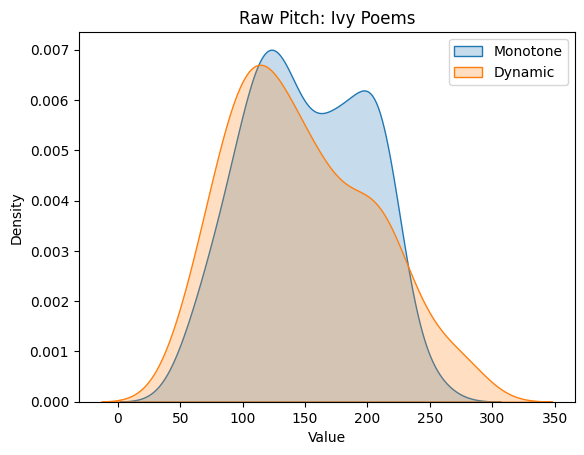

In [134]:
sns.kdeplot(pitch1_no_zero, fill=True, label='Monotone')
sns.kdeplot(pitch2_no_zero, fill=True, label='Dynamic')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Raw Pitch: Ivy Poems")
plt.legend()

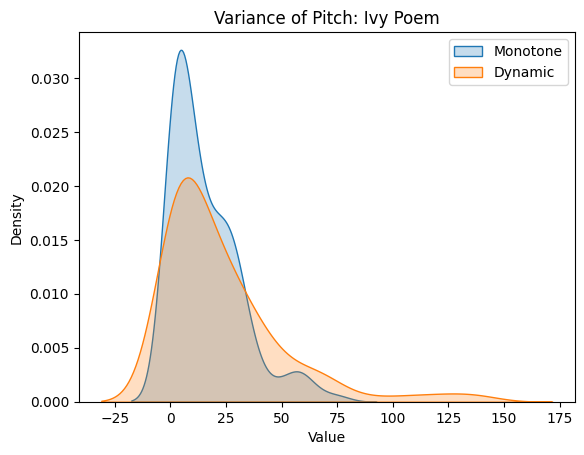

In [135]:
sns.kdeplot(var_pitch1, fill=True, label='Monotone')
sns.kdeplot(var_pitch2, fill=True, label='Dynamic')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Variance of Pitch: Ivy Poem")
plt.legend()

In [117]:
min(var_pitch2)

8.041350053974495e-05

In [118]:
max(var_pitch2)

140.68477539997292

In [119]:
sum(var_pitch2) / len(var_pitch2)

23.4030977326216

In [120]:
np.std(pitch2_no_zero)

np.float64(56.20870211901281)

In [123]:
140+1.5*56

224.0

In [126]:
140+.5*56

168.0

In [124]:
140-1.5*56

56.0

In [ ]:
# find the reasonable range of pitch variance for humans and only look at that range --> replace chopped ones with NaN

# for variance, divide each element - mean squared by the length of list

# 50 - 300 hertz

In [65]:
# raw pitch
combo_no_zero = pitch1_no_zero + pitch2_no_zero
smallest = min(combo_no_zero)
average = sum(combo_no_zero) / len(combo_no_zero)
largest = max(combo_no_zero)
offset_value = (largest - average) * 0.5

print('Smallest: ', smallest)
print('Average: ', average)
print('Largest: ', largest)
print('Offset Value: ', offset_value)

Smallest:  12.974603403522956
Average:  113.27089716425006
Largest:  309.14895889781127
Offset Value:  97.9390308667806


#### Amplitude

In [70]:
amp1_no_zero = list(filter(lambda x: x != 0, audio1['amplitude']))
amp1_mean = sum(amp1_no_zero) / len(amp1_no_zero)
amp2_no_zero = list(filter(lambda x: x != 0, audio2['amplitude']))
amp2_mean = sum(amp2_no_zero) / len(amp2_no_zero)

In [71]:
print('min amp audio 1: ', min(amp1_no_zero))
print('max amp audio 1: ', max(amp1_no_zero))
print('mean amp audio 1: ', amp1_mean)

print('min amp audio 2: ', min(amp2_no_zero))
print('max amp audio 2: ', max(amp2_no_zero))
print('mean amp audio 2: ', amp2_mean)

min amp audio 1:  0.1810573811576722
max amp audio 1:  3.0425643719995374
mean amp audio 1:  1.372501007910885
min amp audio 2:  0.2024308190204314
max amp audio 2:  4.761181143797187
mean amp audio 2:  1.368453380383863


In [75]:
var_amp1 = [(el-amp1_mean)**2 for el in amp1_no_zero]
var_amp2 = [(el-amp2_mean)**2 for el in amp2_no_zero]

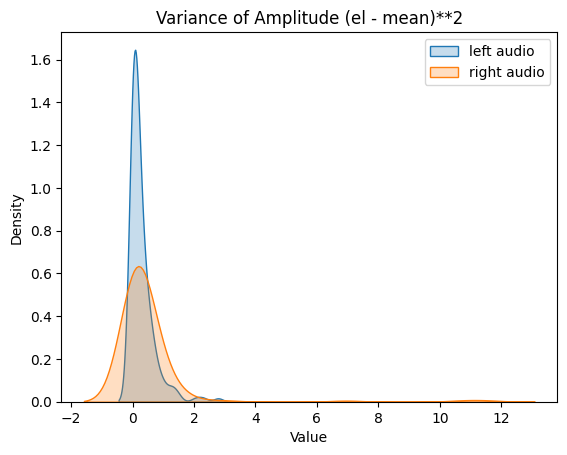

In [78]:
sns.kdeplot(var_amp1, fill=True, label='left audio')
sns.kdeplot(var_amp2, fill=True, label='right audio')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Variance of Amplitude (el - mean)**2")
plt.legend()

In [ ]:
# variance amplitude normalized to right audio (better speech)

In [38]:
import numpy as np

auc = 0.61
se_auc = np.sqrt(auc * (1 - auc) / 85)  # Approximation for SE, not DeLong

# Calculate the CI
lower_bound = round(auc - 1.96 * se_auc, 2)
upper_bound = round(auc + 1.96 * se_auc, 2)

print(lower_bound, upper_bound)

0.51 0.71


### Alex Poems

#### Pitch

In [136]:
audio1 = pd.read_csv('./frontend/src/data/alex_poem_monotone.csv')
audio2 = pd.read_csv('./frontend/src/data/alex_poem_dynamic.csv')

audio1['pitch'] = [el if (el > 50 and el < 300) else np.nan for el in audio1['pitch']]
audio2['pitch'] = [el if (el > 50 and el < 300) else np.nan for el in audio2['pitch']]

In [137]:
pitch1_no_zero = list(filter(lambda x: x != 0 and not np.isnan(x), audio1['pitch']))
pitch1_mean = sum(pitch1_no_zero) / len(pitch1_no_zero)
pitch2_no_zero = list(filter(lambda x: x != 0 and not np.isnan(x), audio2['pitch']))
pitch2_mean = sum(pitch2_no_zero) / len(pitch2_no_zero)

In [138]:
print('min pitch audio 1: ', min(pitch1_no_zero))
print('max pitch audio 1: ', max(pitch1_no_zero))
print('mean pitch audio 1: ', pitch1_mean)

print('min pitch audio 2: ', min(pitch2_no_zero))
print('max pitch audio 2: ', max(pitch2_no_zero))
print('mean pitch audio 2: ', pitch2_mean)

min pitch audio 1:  54.03894266346432
max pitch audio 1:  253.97507393817008
mean pitch audio 1:  150.67961268951464
min pitch audio 2:  50.966733667337635
max pitch audio 2:  211.8182927603232
mean pitch audio 2:  100.46836784550148


In [139]:
var_pitch1 = [(el-pitch1_mean)**2/len(pitch1_no_zero) for el in pitch1_no_zero]
var_pitch2 = [(el-pitch2_mean)**2 /len(pitch2_no_zero) for el in pitch2_no_zero]

# max minus min

In [140]:
# plt.hist(pitch1_no_zero, bins=10, edgecolor='black', label='left audio', alpha=0.6)
# plt.hist(pitch2_no_zero, bins=10, edgecolor='black', label='right audio', alpha=0.6)
# plt.legend()

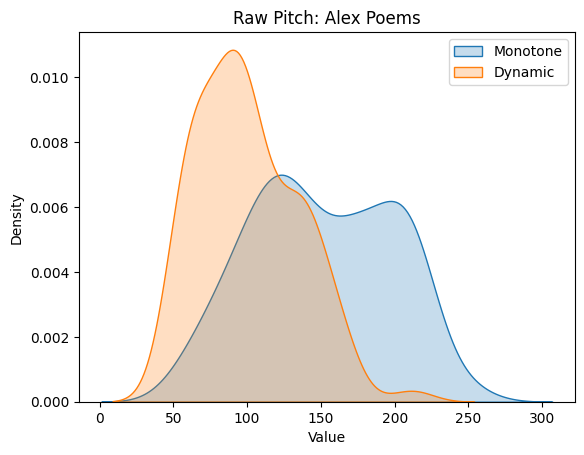

In [147]:
sns.kdeplot(pitch1_no_zero, fill=True, label='Monotone')
sns.kdeplot(pitch2_no_zero, fill=True, label='Dynamic')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Raw Pitch: Alex Poems")
plt.legend()

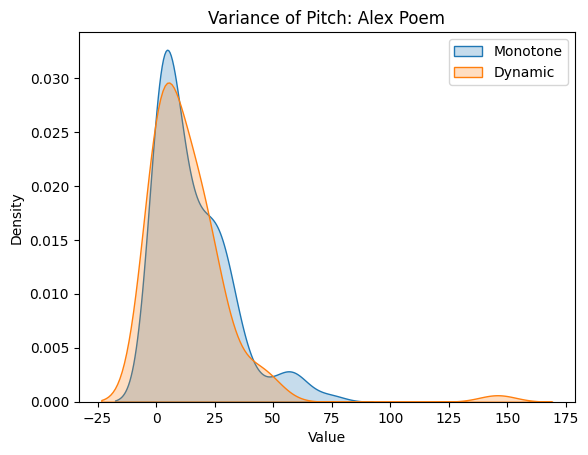

In [148]:
sns.kdeplot(var_pitch1, fill=True, label='Monotone')
sns.kdeplot(var_pitch2, fill=True, label='Dynamic')

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Variance of Pitch: Alex Poem")
plt.legend()

In [143]:
min(var_pitch2)

8.12560912470879e-05

In [144]:
max(var_pitch2)

145.86830327689924

In [145]:
sum(var_pitch2) / len(var_pitch2)

13.55700938891144

In [146]:
np.std(pitch2_no_zero)

np.float64(33.946219201222874)